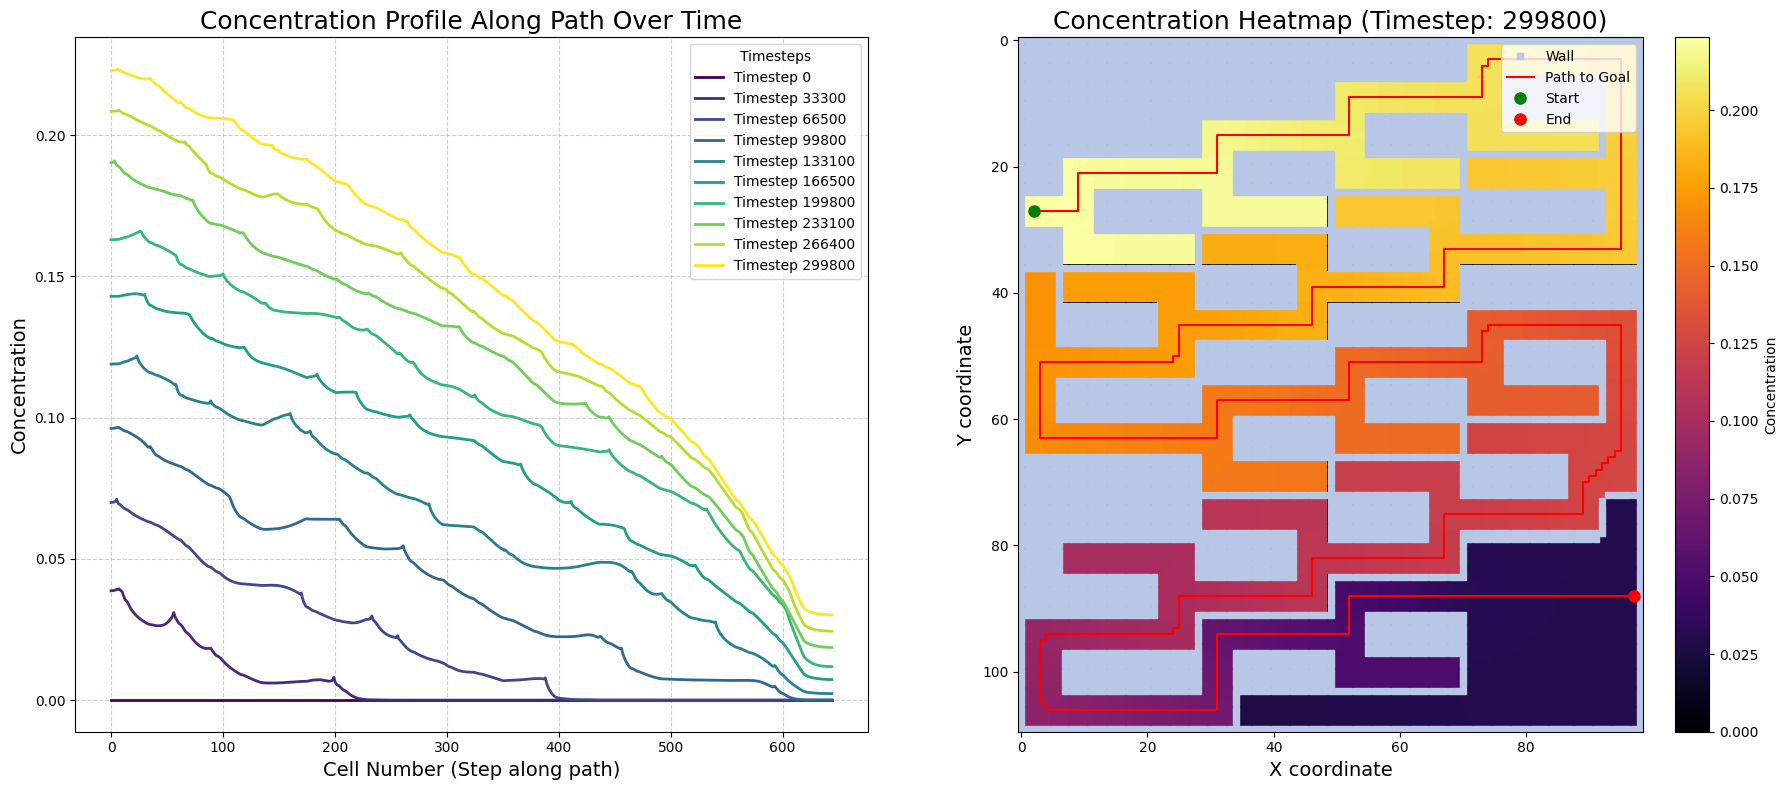

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sys
import os
import glob
import re

# --- 1. Path Extraction and Ordering ---
def extract_and_order_path(maze_array):
    # Find all coordinates where the maze is marked as 2 (the path)
    y_coords, x_coords = np.where(maze_array == 2)
    path_set = set(zip(y_coords, x_coords))
    
    if not path_set:
        raise ValueError("No path (value 2) found in the maze file.")

    def get_neighbors(r, c):
        directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]
        return [(r + dr, c + dc) for dr, dc in directions if (r + dr, c + dc) in path_set]

    endpoints = [node for node in path_set if len(get_neighbors(*node)) == 1]
    start_node = endpoints[0] if endpoints else list(path_set)[0]

    ordered_path = [start_node]
    visited = {start_node}
    current = start_node

    while len(visited) < len(path_set):
        neighbors = get_neighbors(*current)
        unvisited = [n for n in neighbors if n not in visited]
        
        if not unvisited:
            break 
            
        current = unvisited[0]
        ordered_path.append(current)
        visited.add(current)

    return ordered_path

# --- 2. Data Loading & Mapping ---
maze_file = "../different_mazes/Ran_maze_size_prop_to_droplet_testrun_copy.tsv"
try:
    maze = np.loadtxt(maze_file, delimiter='\t')
except OSError:
    print(f"Could not find {maze_file}. Using dummy maze.")
    maze = np.zeros((20, 20))
    maze[5:15, 5] = 2; maze[0:20, 0] = 1; maze[0:20, -1] = 1 

path_coords = extract_and_order_path(maze)

# Find and sort all concentration files
data_dir = "/home/ecasual/Documents/Uni/training-projects/Automated-decision-making-by-chemical-echolocation-in-active-droplets/data"
all_files = glob.glob(os.path.join(data_dir, "conc_*.txt"))

# Helper to extract the timestep integer from the filename (e.g., "100" from "conc_100.txt")
def get_timestep(filepath):
    match = re.search(r'conc_(\d+)\.txt', os.path.basename(filepath))
    return int(match.group(1)) if match else -1

# Filter out any weird files and sort them strictly numerically
valid_files = [f for f in all_files if get_timestep(f) >= 0]
valid_files.sort(key=get_timestep)

# Select 10 evenly spaced files
num_curves = 10
if len(valid_files) > 0:
    indices = np.linspace(0, len(valid_files) - 1, min(num_curves, len(valid_files)), dtype=int)
    selected_files = [valid_files[i] for i in indices]
else:
    selected_files = []
    print(f"No files matching conc_*.txt found in {data_dir}")

# Load data for all selected files
path_data_over_time = {}
last_conc_2d = np.zeros_like(maze, dtype=float) # Fallback / placeholder for heatmap

for file_path in selected_files:
    ts = get_timestep(file_path)
    try:
        conc_1d = np.loadtxt(file_path, skiprows=3).flatten()
        if conc_1d.size == maze.size:
            conc_2d = conc_1d.reshape(maze.shape, order='F')
            
            # ---> USE THE FLIP THAT WORKED FOR YOU HERE <---
            conc_2d = np.flipud(conc_2d) # or np.flipud(conc_2d)
            
            # Extract values along the path
            path_concentrations = [conc_2d[r, c] for r, c in path_coords]
            path_data_over_time[ts] = path_concentrations
            
            # Save the last successful 2D map to display in the heatmap
            last_conc_2d = conc_2d
            
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# --- 3. Plotting ---
plt.style.use("default")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: 1D Concentration Profile (Multiple Curves)
ax1.set_title("Concentration Profile Along Path Over Time", fontsize=18)
ax1.set_xlabel("Cell Number (Step along path)", fontsize=14)
ax1.set_ylabel("Concentration", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# Generate a sequence of colors from the 'viridis' colormap
colors = cm.viridis(np.linspace(0, 1, len(path_data_over_time)))

for (ts, path_conc), color in zip(path_data_over_time.items(), colors):
    ax1.plot(range(len(path_conc)), path_conc, color=color, linewidth=2, label=f"Timestep {ts}")

if path_data_over_time:
    ax1.legend(loc="upper right", fontsize=10, title="Timesteps")

# Subplot 2: 2D Heatmap (Showing the last evaluated timestep)
heatmap = ax2.imshow(last_conc_2d, cmap='inferno', alpha=1.0)
fig.colorbar(heatmap, ax=ax2, fraction=0.046, pad=0.04, label="Concentration")

# Overlay walls
wall_y, wall_x = np.where(maze == 1)
ax2.plot(wall_x, wall_y, "s", markersize=4, color="#B8C7E5", label="Wall")

# Overlay path
path_x = [c for r, c in path_coords]
path_y = [r for r, c in path_coords]
ax2.plot(path_x, path_y, color='red', linewidth=1.5, label="Path to Goal")

ax2.plot(path_x[0], path_y[0], 'go', markersize=8, label="Start")
ax2.plot(path_x[-1], path_y[-1], 'ro', markersize=8, label="End")

# Update title to reflect which timestep is shown
final_ts = list(path_data_over_time.keys())[-1] if path_data_over_time else "Unknown"
ax2.set_title(f"Concentration Heatmap (Timestep: {final_ts})", fontsize=18)
ax2.set_xlabel("X coordinate", fontsize=14)
ax2.set_ylabel("Y coordinate", fontsize=14)
ax2.set_aspect("equal")
ax2.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()
fig.savefig('/home/ecasual/Documents/Uni/droplet-maze/presentations/' + 'Ran_droplet_conc_along_path_05-emission-rate.png', dpi=300, bbox_inches='tight')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB 12.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
import os
import glob
import re

# --- CONFIGURATION FOR THE FADE EFFECT ---
FADE_RATE = 0.7  # 1.0 = No fading (all curves remain fully visible)
                 # 0.0 = Instant fading (only show current timestep)
                 # 0.5 to 0.8 = Smooth gradual fading tail

# --- 1. Path Extraction and Ordering ---
def extract_and_order_path(maze_array):
    y_coords, x_coords = np.where(maze_array == 2)
    path_set = set(zip(y_coords, x_coords))
    
    if not path_set:
        raise ValueError("No path (value 2) found in the maze file.")

    def get_neighbors(r, c):
        directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]
        return [(r + dr, c + dc) for dr, dc in directions if (r + dr, c + dc) in path_set]

    endpoints = [node for node in path_set if len(get_neighbors(*node)) == 1]
    start_node = endpoints[0] if endpoints else list(path_set)[0]

    ordered_path = [start_node]
    visited = {start_node}
    current = start_node

    while len(visited) < len(path_set):
        neighbors = get_neighbors(*current)
        unvisited = [n for n in neighbors if n not in visited]
        if not unvisited:
            break 
        current = unvisited[0]
        ordered_path.append(current)
        visited.add(current)

    return ordered_path

# --- 2. Data Loading ---
maze_file = "../different_mazes/Ran_maze_size_prop_to_droplet_testrun_copy.tsv"
try:
    maze = np.loadtxt(maze_file, delimiter='\t')
except OSError:
    print(f"Could not find {maze_file}. Using dummy 20x20 maze.")
    maze = np.zeros((20, 20))
    maze[5:15, 5] = 2; maze[0:20, 0] = 1; maze[0:20, -1] = 1 

path_coords = extract_and_order_path(maze)

# Find and sort all concentration files
data_dir = "/home/ecasual/Documents/Uni/training-projects/Automated-decision-making-by-chemical-echolocation-in-active-droplets/data"
all_files = glob.glob(os.path.join(data_dir, "conc_*.txt"))

def get_timestep(filepath):
    match = re.search(r'conc_(\d+)\.txt', os.path.basename(filepath))
    return int(match.group(1)) if match else -1

valid_files = [f for f in all_files if get_timestep(f) >= 0]
valid_files.sort(key=get_timestep)

num_curves = 100
if len(valid_files) > 0:
    indices = np.linspace(0, len(valid_files) - 1, min(num_curves, len(valid_files)), dtype=int)
    selected_files = [valid_files[i] for i in indices]
else:
    # Dummy fallback data if files are missing
    selected_files = [f"dummy_conc_{i}.txt" for i in range(10)]
    print(f"No files found in {data_dir}. Running with synthetic demonstration data.")

# Pre-load all concentrations into memory for smooth animation rendering
path_data_over_time = {}
conc_2d_over_time = {}
sorted_timesteps = []

for idx, file_path in enumerate(selected_files):
    ts = get_timestep(file_path) if "dummy" not in file_path else idx * 10
    sorted_timesteps.append(ts)
    
    try:
        if "dummy" in file_path:
            # Generate synthetic propagating peak along the path
            conc_2d = np.zeros_like(maze, dtype=float)
            peak_idx = int((idx / len(selected_files)) * len(path_coords))
            for i, (r, c) in enumerate(path_coords):
                dist = abs(i - peak_idx)
                val = np.exp(-dist**2 / 12.0)
                conc_2d[r, c] = val
        else:
            conc_1d = np.loadtxt(file_path, skiprows=3).flatten()
            conc_2d = conc_1d.reshape(maze.shape, order='F')
            conc_2d = np.flipud(conc_2d)
            
        path_concentrations = [conc_2d[r, c] for r, c in path_coords]
        path_data_over_time[ts] = path_concentrations
        conc_2d_over_time[ts] = conc_2d
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# --- 3. Animation Setup ---
plt.style.use("default")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Static plot elements on Heatmap (Walls, Path, Start/End) to save rendering time
wall_y, wall_x = np.where(maze == 1)
ax2.plot(wall_x, wall_y, "s", markersize=4, color="#B8C7E5", label="Wall")

path_x = [c for r, c in path_coords]
path_y = [r for r, c in path_coords]
ax2.plot(path_x, path_y, color='red', linewidth=1.5, linestyle=':', alpha=0.5, label="Path Track")

ax2.plot(path_x[0], path_y[0], 'go', markersize=8, label="Start")
ax2.plot(path_x[-1], path_y[-1], 'ro', markersize=8, label="End")
ax2.set_xlabel("X coordinate", fontsize=14)
ax2.set_ylabel("Y coordinate", fontsize=14)
ax2.set_aspect("equal")

# Initialize empty heatmap canvas
initial_heatmap = np.zeros_like(maze, dtype=float)
im_heatmap = ax2.imshow(initial_heatmap, cmap='inferno', origin='upper', aspect='equal')
fig.colorbar(im_heatmap, ax=ax2, fraction=0.046, pad=0.04, label="Concentration")
ax2.legend(loc="upper right", fontsize=10)

# Colors sequence for 1D profiles
colors = cm.viridis(np.linspace(0, 1, len(sorted_timesteps)))

# --- 4. Animation Update Function ---
def update_frame(frame_idx):
    current_ts = sorted_timesteps[frame_idx]
    
    # --- Update Subplot 1: 1D Fading Profiles ---
    ax1.clear()
    ax1.set_title("Concentration Profile Along Path Over Time", fontsize=18)
    ax1.set_xlabel("Cell Number (Step along path)", fontsize=14)
    ax1.set_ylabel("Concentration", fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # Find max concentration across all data to set stable limits
    all_vals = [val for lst in path_data_over_time.values() for val in lst]
    max_val = max(all_vals) if all_vals else 1.0
    ax1.set_ylim(-0.05, max_val * 1.1)
    
    # Plot history up to current frame with fading opacity
    for i in range(frame_idx + 1):
        hist_ts = sorted_timesteps[i]
        path_conc = path_data_over_time[hist_ts]
        age = frame_idx - i
        
        # Exponential fade formula
        alpha = max(0.02, FADE_RATE ** age) 
        
        # Highlight the active (most recent) line with a thicker stroke
        linewidth = 3 if i == frame_idx else 1.5
        label = f"Timestep {hist_ts}" if i == frame_idx or age <= 1 else ""
        
        ax1.plot(range(len(path_conc)), path_conc, color=colors[i], 
                 alpha=alpha, linewidth=linewidth, label=label)
        
    ax1.legend(loc="upper right", fontsize=10, title="Active Frame")

    # --- Update Subplot 2: 2D Fading Heatmap ---
    # Accumulate and decay historical matrices
    accumulated_heatmap = np.zeros_like(maze, dtype=float)
    for i in range(frame_idx + 1):
        hist_ts = sorted_timesteps[i]
        age = frame_idx - i
        accumulated_heatmap += conc_2d_over_time[hist_ts] * (FADE_RATE ** age)
        
    im_heatmap.set_data(accumulated_heatmap)
    
    # Set high-contrast dynamically matching local intensity peaks
    current_max = max(1e-5, accumulated_heatmap.max())
    im_heatmap.set_clim(vmin=0, vmax=current_max)
    
    ax2.set_title(f"Concentration Heatmap (Timestep: {current_ts})", fontsize=18)
    
    return im_heatmap,

# --- 5. Run and Save Animation ---
ani = animation.FuncAnimation(
    fig, update_frame, frames=len(sorted_timesteps), interval=1000, blit=False
)

plt.tight_layout()

# Save options (uncomment the one you want to use):
# Option A: Save as MP4 Video (Requires 'ffmpeg' installed on your system)
video_path = '/home/ecasual/Documents/Uni/droplet-maze/presentations/concentration_fade_animation.mp4'
try:
    writer = animation.FFMpegWriter(fps=1, metadata=dict(artist='Me'), bitrate=1800)
    ani.save(video_path, writer=writer)
    print(f"Successfully saved MP4 video to {video_path}")
except Exception as e:
    print(f"Could not save MP4 (likely missing ffmpeg): {e}")

# Option B: Save as GIF (Requires 'pillow' library)
# gif_path = '/home/ecasual/Documents/Uni/droplet-maze/presentations/concentration_fade_animation.gif'
# ani.save(gif_path, writer='pillow', fps=1)

plt.show()

Successfully saved MP4 video to /home/ecasual/Documents/Uni/droplet-maze/presentations/concentration_fade_animation.mp4


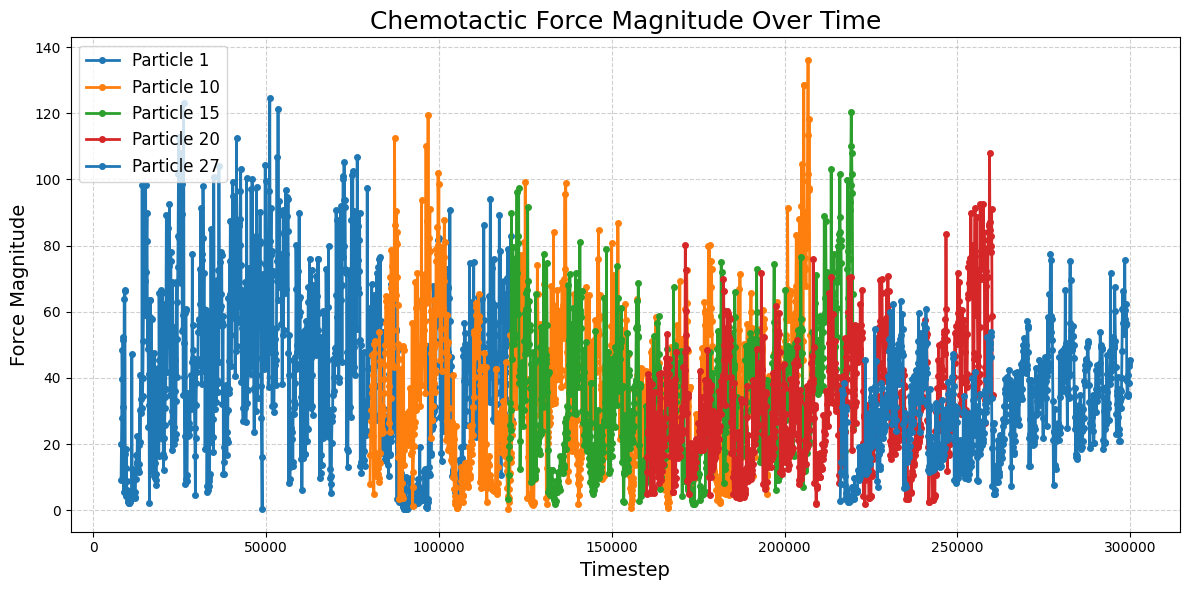

In [46]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup and File Discovery ---
data_dir = "/home/ecasual/Documents/Uni/training-projects/Automated-decision-making-by-chemical-echolocation-in-active-droplets/data"
# Find all particle files
all_files = glob.glob(os.path.join(data_dir, "part_*.txt"))


# Helper to extract timestep from filename
def get_timestep(filepath):
    match = re.search(r"part_(\d+)\.txt", os.path.basename(filepath))
    return int(match.group(1)) if match else -1


# Sort files chronologically
valid_files = [f for f in all_files if get_timestep(f) >= 0]
valid_files.sort(key=get_timestep)

# --- 2. Define Targets and Storage ---
# Choose the particles you want to plot (e.g., 24 and 25)
target_particles = [1, 10, 15, 20, 27]

# Dictionary to hold the time ('t') and force magnitude ('f_mag') for each particle
particle_history = {pid: {"t": [], "f_mag": []} for pid in target_particles}

# --- 3. Process Data Files ---
for file_path in valid_files:
    ts = get_timestep(file_path)

    try:
        with open(file_path, "r") as f:
            lines = f.readlines()

        # Skip the TIMESTEP and DATA headers (usually the first 3 lines)
        # We also ignore any empty lines or comments starting with '#'
        data_lines = [
            line.strip().split()
            for line in lines[3:]
            if line.strip() and not line.startswith("#")
        ]

        if not data_lines:
            continue

        # Identify the last particle's exact position to filter inactive particles
        last_row = data_lines[-1]
        last_x, last_y = last_row[1], last_row[2]

        for row in data_lines:
            pid = int(row[0])

            # Only process if it's a particle we care about
            if pid not in target_particles:
                continue

            x_str, y_str = row[1], row[2]

            # Condition A: Particle removed (nan positions)
            if x_str.lower() == "nan" or y_str.lower() == "nan":
                continue

            # Condition B: Particle inactive (shares exact coordinates with the last particle)
            if x_str == last_x and y_str == last_y:
                continue

            # If it passes the checks, extract the forces (Indices 9 and 10 based on your header)
            f_chemx = float(row[9])
            f_chemy = float(row[10])

            # Calculate the overall magnitude of the chemotactic force
            force_magnitude = np.sqrt(f_chemx**2 + f_chemy**2)

            # Store the valid data
            particle_history[pid]["t"].append(ts)
            particle_history[pid]["f_mag"].append(force_magnitude)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# --- 4. Plotting ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # Standard distinct colors

# Plot a line for each targeted particle
for idx, pid in enumerate(target_particles):
    t_data = particle_history[pid]["t"]
    f_data = particle_history[pid]["f_mag"]

    if t_data:  # Only plot if we actually collected data for this particle
        ax.plot(
            t_data,
            f_data,
            marker="o",
            markersize=4,
            linewidth=2,
            color=colors[idx % len(colors)],
            label=f"Particle {pid}",
        )
    else:
        print(f"No active data found for Particle {pid}.")

ax.set_title("Chemotactic Force Magnitude Over Time", fontsize=18)
ax.set_xlabel("Timestep", fontsize=14)
ax.set_ylabel("Force Magnitude", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('/home/ecasual/Documents/Uni/droplet-maze/presentations/' + 'Ran_droplet_f_chem_rough_05-emission-rate.png', dpi=300, bbox_inches='tight')

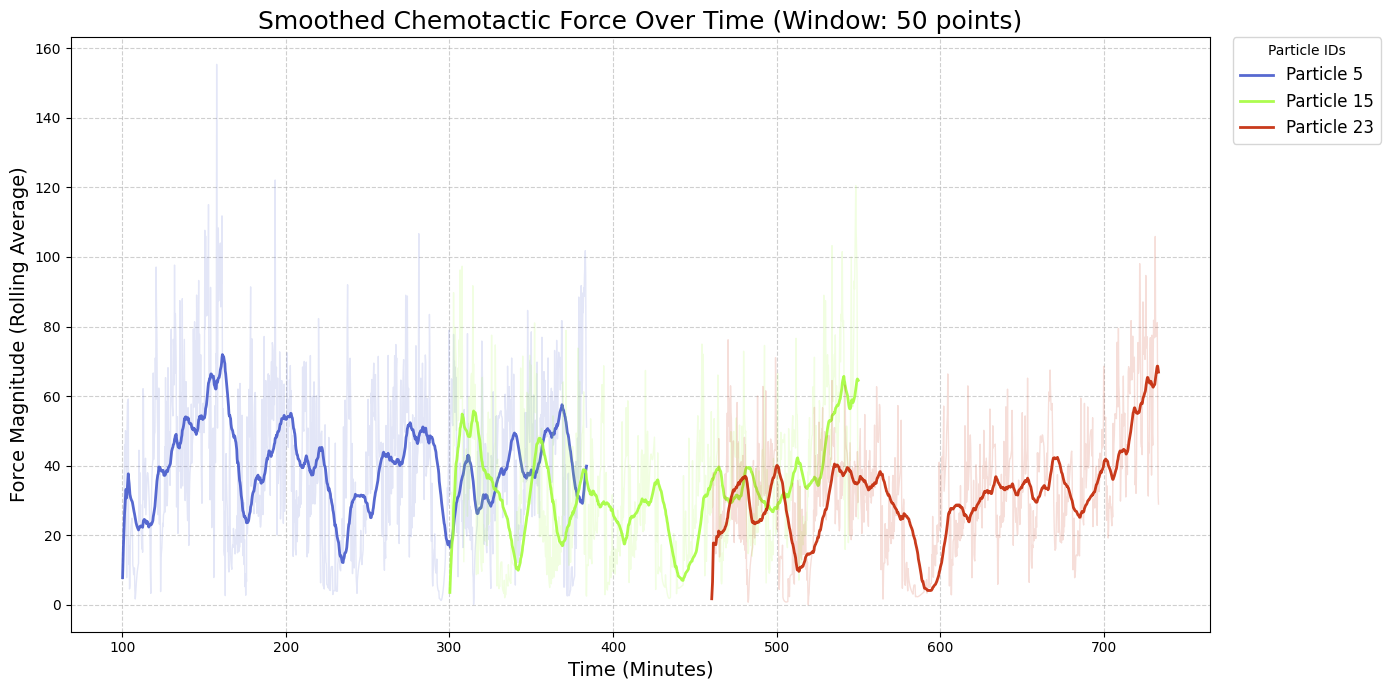

In [47]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- 1. Setup and File Discovery ---
data_dir = "/home/ecasual/Documents/Uni/training-projects/Automated-decision-making-by-chemical-echolocation-in-active-droplets/data"
all_files = glob.glob(os.path.join(data_dir, "part_*.txt"))

def get_timestep(filepath):
    match = re.search(r'part_(\d+)\.txt', os.path.basename(filepath))
    return int(match.group(1)) if match else -1

valid_files = [f for f in all_files if get_timestep(f) >= 0]
valid_files.sort(key=get_timestep)

# --- 2. Define Targets and Parameters ---
target_particles = [5,15,23]  # Put your 4 specific PIDs here
window_size = 50 

# Time conversion constants
dt = 0.00025
time_factor = 10

# We will store 't_mins' instead of the raw timestep 't'
particle_history = {pid: {'t_mins': [], 'f_mag': []} for pid in target_particles}

# --- 3. Process Data Files ---
for file_path in valid_files:
    ts = get_timestep(file_path)
    
    # Convert timestep to real minutes immediately
    current_time_mins = (ts * dt * time_factor)
    
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
            
        data_lines = [line.strip().split() for line in lines[3:] if line.strip() and not line.startswith('#')]
        
        if not data_lines:
            continue
            
        last_row = data_lines[-1]
        last_x, last_y = last_row[1], last_row[2]
        
        for row in data_lines:
            pid = int(row[0])
            
            if pid not in target_particles:
                continue
                
            x_str, y_str = row[1], row[2]
            
            # Skip inactive or removed particles
            if x_str.lower() == 'nan' or y_str.lower() == 'nan':
                continue
            if x_str == last_x and y_str == last_y:
                continue
                
            f_chemx = float(row[9])
            f_chemy = float(row[10])
            force_magnitude = np.sqrt(f_chemx**2 + f_chemy**2)
            
            particle_history[pid]['t_mins'].append(current_time_mins)
            particle_history[pid]['f_mag'].append(force_magnitude)
            
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# --- 4. Plotting with Rolling Averages ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(14, 7))

# Generate distinct colors for exactly the number of targeted particles
colors = cm.turbo(np.linspace(0.1, 0.9, len(target_particles)))

for idx, pid in enumerate(target_particles):
    t_data = particle_history[pid]['t_mins']
    f_data = particle_history[pid]['f_mag']
    
    if not t_data:
        print(f"No active data found for Particle {pid}.")
        continue
        
    f_series = pd.Series(f_data)
    f_smooth = f_series.rolling(window=window_size, min_periods=1).mean()
    
    # Background raw data
    ax.plot(t_data, f_data, color=colors[idx], alpha=0.15, linewidth=1)
    
    # Foreground smoothed data
    ax.plot(t_data, f_smooth, color=colors[idx], alpha=0.9, linewidth=2, label=f"Particle {pid}")

ax.set_title(f"Smoothed Chemotactic Force Over Time (Window: {window_size} points)", fontsize=18)
ax.set_xlabel("Time (Minutes)", fontsize=14)
ax.set_ylabel("Force Magnitude (Rolling Average)", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)

# Place legend outside
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12, 
          title="Particle IDs", borderaxespad=0.)

plt.tight_layout()
plt.show()

fig.savefig('/home/ecasual/Documents/Uni/droplet-maze/presentations/' + 'Ran_droplet_f_chem_smooth_05-emission-rate.png', dpi=300, bbox_inches='tight')